In [1]:
from sklearn.datasets import load_files

In [4]:
file_path = "cv000_29416.txt"

with open(file_path, "r", encoding="utf-8") as file:
    data = file.read()

print(type(data))
print(data[:1000])

<class 'str'>
plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn't snag this one correctly . 
they seem to have taken this pretty neat concept , but executed it terribly . 
so what are the problems with the movie ? 
well , its main problem is that it's simply too jumbled . 
it starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience membe

In [12]:
movie = load_files("review_polarity/txt_sentoken")

In [13]:
x , y = movie.data , movie.target

In [14]:
len(x)

1999

In [15]:
len(y)

1999

In [16]:
import re

In [19]:
lst = []
from nltk.stem import WordNetLemmatizer

stemmer = WordNetLemmatizer()

In [21]:
lst = []
import re
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

for sen in range(len(x)):
    # convert bytes to string
    txt = x[sen].decode('utf-8')
    
    # remove non-alphabet characters
    txt = re.sub(r'\W', ' ', txt)
    
    # remove single characters
    txt = re.sub(r'\s+[a-zA-Z]\s+', ' ', txt)
    txt = re.sub(r'^[a-zA-Z]\s+', ' ', txt)
    
    # remove extra spaces
    txt = re.sub(r'\s+', ' ', txt)
    
    # lowercase
    txt = txt.lower()
    
    # tokenize
    txt = txt.split()
    
    # lemmatize
    txt = [lemmatizer.lemmatize(word) for word in txt]
    
    # join back
    txt = ' '.join(txt)
    
    lst.append(txt)

print("Processed sentences:", len(lst))

Processed sentences: 1999


In [25]:
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer

In [26]:
convert = TfidfVectorizer(stop_words = stopwords.words("english"))

In [27]:
x = convert.fit_transform(lst).toarray()

In [28]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 0)

In [29]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(n_estimators = 200 , random_state = 0)

In [30]:
model.fit(x_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [31]:
model.score(x_test, y_test)

0.8025

In [32]:
# create confusion matrix
y_pred = model.predict(x_test)

In [33]:
y_pred

array([0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1,
       1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0,
       1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1,

In [35]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[168  30]
 [ 49 153]]


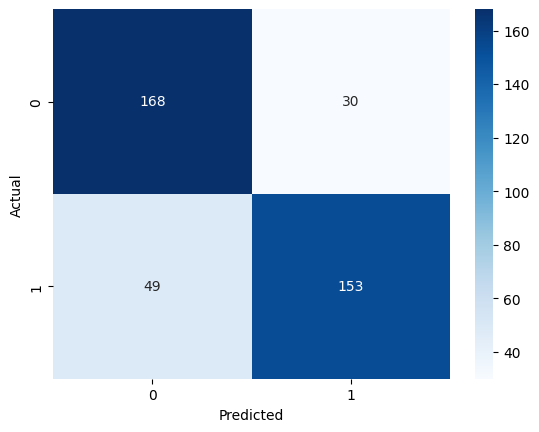

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [37]:
rev1 = "this movie was terrible and bad"
rev2 = "i really liked the movie and enjoyed a lot"

In [39]:
x1 = convert.transform([rev1, rev2]).toarray()

In [40]:
model.predict(x1)

array([0, 1])

In [42]:
import joblib
# save model
joblib.dump(model, "sentiment_model.pkl")

['sentiment_model.pkl']